In [34]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
%matplotlib inline

## Q1

In [35]:
# loading data
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]

print(D.shape)
D[:5]

(100, 6)


array([[ -5.30547099,  -4.06009155,  -5.26129006, -12.66633342,
         -3.79615021,   3.69171161],
       [ -5.5403588 ,  -5.0031803 ,  -3.99259187, -11.00772693,
         -3.98562503,   4.90000402],
       [ -4.98212753,  -4.58449362,  -4.33122591, -11.69731474,
         -3.58927699,   5.04686274],
       [ -4.49570614,  -5.06413838,  -4.78201809, -11.97801037,
         -3.59707103,   4.63593624],
       [ -4.44215386,  -4.41137023,  -4.5675092 , -12.41495176,
         -2.79950409,   4.73969871]])

### (a) TLS on first line

In [36]:
x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]

In [37]:
def tls_fit(x, y):
    """fit line ax + by + c = 0 using total least squares"""
    xm = np.mean(x)
    ym = np.mean(y)
    A = np.column_stack([x - xm, y - ym])
    U, S, Vt = np.linalg.svd(A)
    a, b = Vt[-1]
    c = -(a * xm + b * ym)
    return a, b, c

In [38]:
a, b, c = tls_fit(x1, y1)
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print()
m = -a/b
d = -c/b
print(f"y = {m:.4f}x + ({d:.4f})")

a = 0.773562
b = -0.633721
c = -3.794192

y = 1.2207x + (-5.9872)


#### Comparing TLS vs OLS

In [39]:
# OLS fit for comparison
ols_coeffs = np.polyfit(x1, y1, 1)
m_ols, d_ols = ols_coeffs
print(f"OLS: y = {m_ols:.4f}x + ({d_ols:.4f})")
print(f"TLS: y = {m:.4f}x + ({d:.4f})")
print(f"\nslope diff: {abs(m - m_ols):.6f}")
print(f"intercept diff: {abs(d - d_ols):.6f}")

OLS: y = 1.1845x + (-5.9879)
TLS: y = 1.2207x + (-5.9872)

slope diff: 0.036192
intercept diff: 0.000706


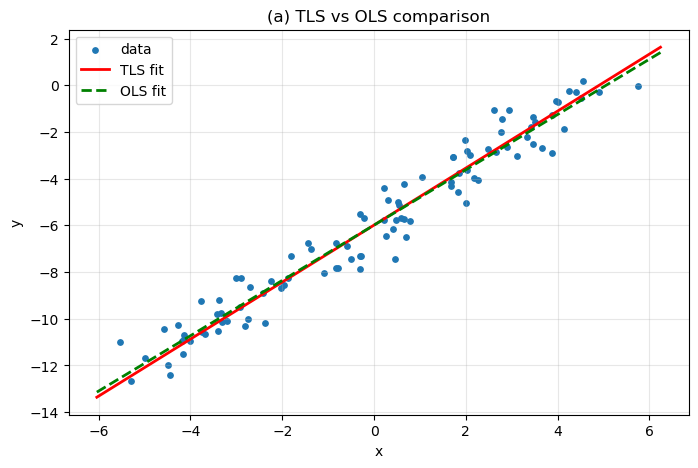

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(x1, y1, s=15, label='data')
xs = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 200)
plt.plot(xs, (-a * xs - c) / b, 'r-', lw=2, label='TLS fit')
plt.plot(xs, m_ols * xs + d_ols, 'g--', lw=2, label='OLS fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('(a) TLS vs OLS comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [41]:
# compare residuals
tls_residuals = np.abs(a * x1 + b * y1 + c)
ols_residuals = np.abs(y1 - (m_ols * x1 + d_ols))
print(f"TLS mean orthogonal residual: {np.mean(tls_residuals):.4f}")
print(f"OLS mean vertical residual:   {np.mean(ols_residuals):.4f}")
print(f"\nTLS gives smaller orthogonal errors since it minimises perpendicular distance")

TLS mean orthogonal residual: 0.4059
OLS mean vertical residual:   0.6422

TLS gives smaller orthogonal errors since it minimises perpendicular distance


### (b) RANSAC to fit 3 lines

In [42]:
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print(f"total points: {len(X_all)}")

total points: 300


In [43]:
def ransac_line(x, y, n_iter=2000, thresh=0.5):
    n = len(x)
    best_count = 0
    best_params = None
    best_mask = None
    for _ in range(n_iter):
        idx = np.random.choice(n, 2, replace=False)
        xs, ys = x[idx], y[idx]
        dx = xs[1] - xs[0]
        dy = ys[1] - ys[0]
        length = np.sqrt(dx**2 + dy**2)
        if length < 1e-12:
            continue
        a = -dy / length
        b = dx / length
        c = -(a * xs[0] + b * ys[0])
        dists = np.abs(a * x + b * y + c)
        mask = dists < thresh
        count = np.sum(mask)
        if count > best_count:
            best_count = count
            best_params = (a, b, c)
            best_mask = mask
    # refit with tls on inliers
    if best_mask is not None and np.sum(best_mask) >= 2:
        a2, b2, c2 = tls_fit(x[best_mask], y[best_mask])
        dists = np.abs(a2 * x + b2 * y + c2)
        best_mask = dists < thresh
        best_params = (a2, b2, c2)
    return best_params, best_mask

In [44]:
rem_x = X_all.copy()
rem_y = Y_all.copy()
rem_idx = np.arange(len(X_all))
lines = []
inlier_sets = []
for i in range(3):
    params, mask = ransac_line(rem_x, rem_y)
    a_r, b_r, c_r = params
    m_r = -a_r/b_r
    d_val = -c_r/b_r
    print(f"Line {i+1}: y = {m_r:.4f}x + ({d_val:.4f}), inliers: {np.sum(mask)}")
    lines.append(params)
    inlier_sets.append(rem_idx[mask])
    rem_x = rem_x[~mask]
    rem_y = rem_y[~mask]
    rem_idx = rem_idx[~mask]

Line 1: y = -0.5056x + (2.1804), inliers: 82
Line 2: y = 1.0348x + (1.0486), inliers: 67
Line 3: y = 1.3126x + (-5.9053), inliers: 64


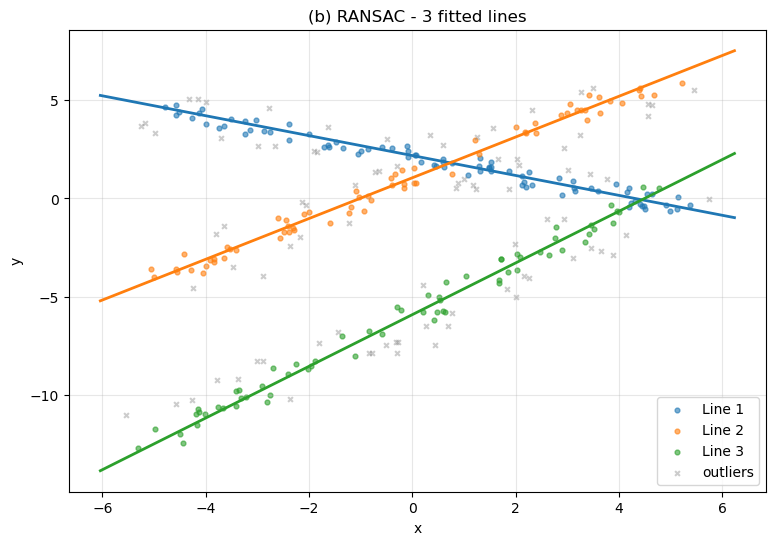

In [45]:
plt.figure(figsize=(9, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']
xp = np.linspace(X_all.min() - 0.5, X_all.max() + 0.5, 300)
for i, (params, inliers) in enumerate(zip(lines, inlier_sets)):
    a_r, b_r, c_r = params
    plt.scatter(X_all[inliers], Y_all[inliers], s=12, color=colors[i], alpha=0.6, label=f'Line {i+1}')
    plt.plot(xp, (-a_r * xp - c_r) / b_r, color=colors[i], lw=2)
if len(rem_x) > 0:
    plt.scatter(rem_x, rem_y, s=12, color='gray', alpha=0.4, marker='x', label='outliers')
plt.xlabel('x')
plt.ylabel('y')
plt.title('(b) RANSAC - 3 fitted lines')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Comparing TLS (part a) vs RANSAC (part b)

In [46]:
a_tls, b_tls, c_tls = tls_fit(x1, y1)
m_tls = -a_tls / b_tls
d_tls = -c_tls / b_tls
print("TLS (part a):")
print(f"  y = {m_tls:.4f}x + ({d_tls:.4f})")
print()
print("RANSAC lines (part b):")
for i, (a_r, b_r, c_r) in enumerate(lines):
    m_r = -a_r / b_r
    d_r = -c_r / b_r
    slope_diff = abs(m_tls - m_r)
    print(f"  Line {i+1}: y = {m_r:.4f}x + ({d_r:.4f}), slope diff from TLS = {slope_diff:.4f}")
print()
print("The RANSAC line with closest slope corresponds to the same underlying line.")
print("Small differences because RANSAC used pooled data while TLS had labelled points.")

TLS (part a):
  y = 1.2207x + (-5.9872)

RANSAC lines (part b):
  Line 1: y = -0.5056x + (2.1804), slope diff from TLS = 1.7263
  Line 2: y = 1.0348x + (1.0486), slope diff from TLS = 0.1859
  Line 3: y = 1.3126x + (-5.9053), slope diff from TLS = 0.0919

The RANSAC line with closest slope corresponds to the same underlying line.
Small differences because RANSAC used pooled data while TLS had labelled points.
